In [1]:
import boto3
import botocore
from iterdub import iterdub as ib
import matplotlib.pyplot as plt
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import make_outattr_metadata
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmez679
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: bucket=prq49--a=all_stints_all_series_profiles+endeavor=16--x=complexity-fitness
notebook path: /home/runner/work/oee4/oee4/binder/bucket=prq49--a=all_stints_all_series_profiles+endeavor=16--x=complexity-fitness.ipynb
revision: bdac574
timestamp: 2026-02-22T03:05:07Z00:00

IPython==7.16.1
packaging==26.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


# get data


In [4]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

series_profiles, = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/series-profiles/stage=8+what=elaborated/',
)


In [5]:
df = pd.read_csv(
    f's3://prq49/{series_profiles.key}',
    compression='xz',
)
dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
dfdigest


<ipython-input-5-747b1fe91af5>:1: DtypeWarning: Columns (2270,2277,2284,2285,2286,2287,2289,2290,2291,2292,2298,2299,2300,2301,2302,2308,2309,2310) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


'-1af9f0eb89153a8e'

In [6]:
for stint in df['Stint'].unique():
    exec(f'df{stint} = df[ df["Stint"] == {stint} ]')


In [7]:
dfm10 = df[ df['Stint'] % 10 == 0 ]


# how do fitness and phenotypic complexity relate?


In [8]:
# tp.tee(
#     sns.regplot,
#     data=df40,
#     x='Phenotype Complexity',
#     y='Fraction Inter-Strain Competitions Won',
#     teeplot_outattrs={
#         **{
#             'bucket' : ib.dub( df['Treatment bucket'] ),
#             'endeavor' : ib.dub( df['Endeavor'] ),
#             'transform' : 'filter-Stint-40',
#             '_dfdigest' : dfdigest,
#         },
#         **make_outattr_metadata(),
#     },
# )


In [9]:
# groupby_Series_mean_df = df.groupby('Series').mean()
# tp.tee(
#     sns.regplot,
#     data=groupby_Series_mean_df,
#     x='Phenotype Complexity',
#     y='Fraction Inter-Strain Competitions Won',
#     teeplot_outattrs={
#         **{
#             'bucket' : ib.dub( df['Treatment bucket'] ),
#             'endeavor' : ib.dub( df['Endeavor'] ),
#             'transform' : 'groupby-Series-mean',
#             '_dfdigest' : dfdigest,
#         },
#         **make_outattr_metadata(),
#     },
# )
# stats.pearsonr(
#     df.groupby('Series')['Phenotype Complexity'].mean(),
#     df.groupby('Series')['Fraction Inter-Strain Competitions Won'].mean(),
# )


# how do fitness and fitness complexity relate?



slope=-0.005936727104624421
intercept=0.5807126863988576
r_value=-0.210917586024645
p_value=0.19141191601581928
std_err=0.004463350278181762

teeplots/viz=regplot+x=fitness-complexity+y=fraction-inter-strain-competitions-won+ext=.pdf
teeplots/viz=regplot+x=fitness-complexity+y=fraction-inter-strain-competitions-won+ext=.png


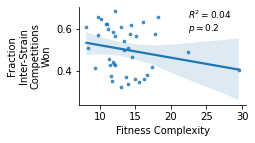

In [10]:
data = dfm10.groupby("Series").mean(numeric_only=True).reset_index()
with tp.teed(
    sns.regplot,
    data=data,
    x="Fitness Complexity",
    y="Fraction Inter-Strain Competitions Won",
    scatter_kws={"s": 7},
) as ax:
    ax.figure.set_size_inches(3, 1.8)
    sns.despine(ax=ax)
    slope, intercept, r_value, p_value, std_err = map(
        float,
        stats.linregress(
            data["Fitness Complexity"],
            data["Fraction Inter-Strain Competitions Won"]
        ),
    )
    ax.set_ylabel("Fraction\nInter-Strain\nCompetitions\nWon")
    ax.annotate(
        f"$R^2 = {r_value**2:.2f}$\n$p= {p_value:.1}$",
        xy=(0.65, 0.85),
        xycoords="axes fraction",
        ha="left",
        va="center",
        fontsize=9,
    )
    print(f"""
{slope=}
{intercept=}
{r_value=}
{p_value=}
{std_err=}
""")
